# Imports

In [325]:
import torch
import torch.nn as nn

import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt

# Dataset
Previous Image

- View 1:

    - Crop, Flip

- View 2:

    - Crop, Color Jitter

Insted 
- context and target
- split the image into 2
- image 1:
    - cat head & body
- image 2:
    - tail

In [326]:
transform = transforms.ToTensor()

# change 1, from v2
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform,
)

# Get Images

In [327]:
image, _ = dataset[0]

[]

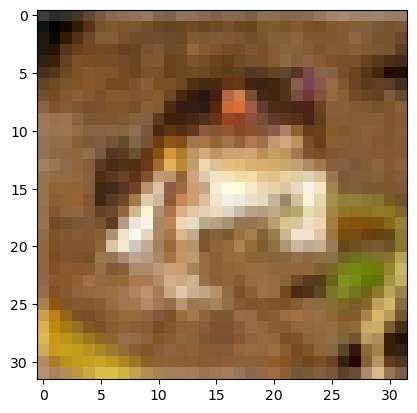

In [328]:
plt.imshow(image.permute(1, 2, 0))
plt.plot()

# split image into context and target

In [329]:
context = image[:, :16, :]
target = image[:, 16:, :]

In [330]:
print(context.shape)
print(target.shape)

torch.Size([3, 16, 32])
torch.Size([3, 16, 32])


# View

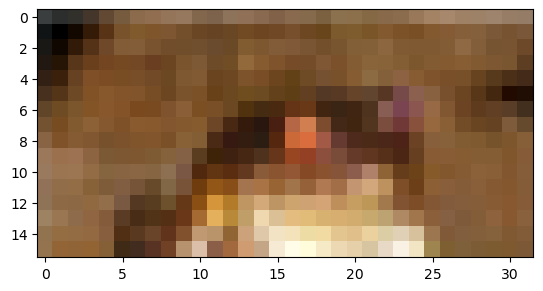

In [331]:
plt.imshow(context.permute(1, 2, 0))
plt.show()

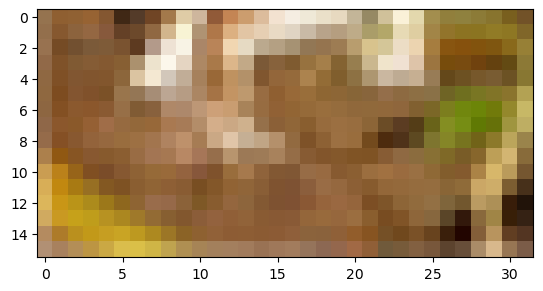

In [332]:
plt.imshow(target.permute(1, 2, 0))
plt.show()

# Add batch Dim

In [333]:
context = context.unsqueeze(0)
target = target.unsqueeze(0)

# Encoder

In [334]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                3 * 16 * 32,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256, 
                128
            )

        )

    def forward(self, x):
        return self.encoder(x)

# Predictor

In [335]:
class Predictor(nn.Module):

    def __init__(self):
        super().__init__()

        self.predictor = nn.Sequential(

            nn.Linear(128, 256),

            nn.ReLU(),

            nn.Linear(256, 128)
        )

    def forward(self, x):
        return self.predictor(x)

# Create Models

In [336]:
context_encoder = Encoder()

target_encoder = Encoder()

predictor = Predictor()

# Copy Weights

In [337]:
target_encoder.load_state_dict(
    context_encoder.state_dict()
)

<All keys matched successfully>

# Freeze Target Encoder

In [338]:
for param in target_encoder.parameters():
    param.requires_grad = False

# Loss Function

In [339]:
loss_fn = nn.MSELoss()

# Optimizer

In [340]:
optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) +
    list(predictor.parameters()),
    lr=0.001
)

# Full Architecture

Full image -> context -> first half of image and target -> sencond half of image

context -> online Encoder -> z1 -> predictor -> pred_z2

target -> target Encoder -> z2

Cosine Loss

# Training Loop

In [341]:
for epoch in range(500):

    context = image[:, :16, :]
    target = image[:, 16:, :]

    context = context.unsqueeze(0)
    target = target.unsqueeze(0)

    # find pred z2 using z1
    z1 = context_encoder(context)
    pred_z2 = predictor(z1)

    # find actual z2
    with torch.no_grad():
        z2 = target_encoder(target)
    
    # find loss
    # loss = loss_fn(z2, pred_z2)

    # real BYOL uses cosine similarity
    loss = 1 - F.cosine_similarity(
    pred_z2,
    z2,
    dim=1
    ).mean()

    # This update context_encoder
    optimizer.zero_grad() # Clear the old math.
    loss.backward() # This function performs the actual backpropagation, but it only does the math.
    optimizer.step() # This is where the actual updating happens.

    # update target_encoder (EMA)
    for target_param, online_param in zip(
        target_encoder.parameters(),
        context_encoder.parameters()
    ):
        
        # formula to update target_encoder a small step
        # like .2 .2 .2
        m = 0.99
        target_param.data = (m * target_param.data) + ((1-m) * online_param.data)

    print(epoch, loss.item())



0 0.8560627102851868
1 0.4679940938949585
2 0.26195013523101807
3 0.15246450901031494
4 0.0905611515045166
5 0.053130507469177246
6 0.036644816398620605
7 0.034372568130493164
8 0.03699910640716553
9 0.03922837972640991
10 0.03941148519515991
11 0.03795421123504639
12 0.03564268350601196
13 0.032691121101379395
14 0.028987586498260498
15 0.024691224098205566
16 0.020535290241241455
17 0.016944825649261475
18 0.014126956462860107
19 0.0118560791015625
20 0.009953498840332031
21 0.00835639238357544
22 0.007157325744628906
23 0.006253838539123535
24 0.0055640339851379395
25 0.005016446113586426
26 0.004556715488433838
27 0.004137873649597168
28 0.0037268996238708496
29 0.0033278465270996094
30 0.002962052822113037
31 0.00261688232421875
32 0.0022884011268615723
33 0.001979351043701172
34 0.0016968250274658203
35 0.0014459490776062012
36 0.0012322664260864258
37 0.0010570287704467773
38 0.0009188055992126465
39 0.0008118748664855957
40 0.0007307529449462891
41 0.0006676316261291504
42 0.00

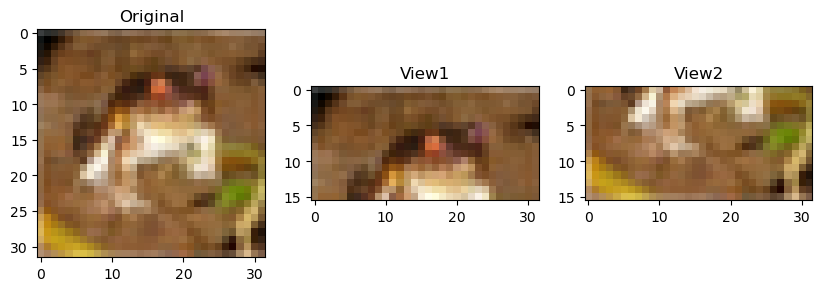

In [342]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(context.squeeze(0).permute(1,2,0))
plt.title("View1")

plt.subplot(1,3,3)
plt.imshow(target.squeeze(0).permute(1,2,0))
plt.title("View2")

plt.show()

In [343]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    z1,
    z2,
    dim=1
)

print(similarity)

tensor([0.9999], grad_fn=<SumBackward1>)


In [344]:
print(context.shape)
print(target.shape)

torch.Size([1, 3, 16, 32])
torch.Size([1, 3, 16, 32])


In [345]:
z2

tensor([[-2.2692e+00,  5.0653e-01, -3.0776e+00, -5.2938e+00, -1.9529e+00,
         -2.0274e+00, -6.1491e+00, -1.6828e+00,  7.5993e-01,  4.9406e+00,
          7.2781e-01, -3.5403e+00,  3.5032e+00, -3.4573e+00, -2.3619e+00,
          1.3773e+00,  3.3672e+00, -3.9701e+00, -8.6623e-01, -2.6694e+00,
          4.7636e+00,  4.8401e+00,  6.0417e+00, -1.4996e+00,  1.6307e+00,
         -2.6952e+00, -2.5691e+00, -4.6779e+00, -5.9086e-01, -3.4220e+00,
         -6.7066e+00,  1.5996e+00, -3.5386e+00,  5.0685e+00, -1.8160e+00,
         -4.1541e+00, -9.0342e+00,  6.9725e-03,  9.6566e-01,  2.8818e+00,
          6.5877e+00, -4.7100e-02, -7.4170e+00,  1.3150e+00, -4.1143e+00,
         -3.5876e+00, -6.1998e+00, -3.1280e+00, -5.7369e+00, -3.6030e+00,
          2.1738e+00, -1.2629e-02,  1.5839e+00,  8.0635e-01,  1.2402e-01,
         -5.7063e-01, -2.8879e+00,  4.6668e+00, -3.4820e+00,  4.3428e+00,
          3.7017e+00,  4.4577e+00, -5.2239e+00, -2.2674e+00,  2.1197e+00,
          6.3245e+00,  2.2792e+00,  5.

In [346]:
pred_z2

tensor([[-2.4936e+00,  5.5777e-01, -3.3820e+00, -5.8173e+00, -2.1461e+00,
         -2.2279e+00, -6.7572e+00, -1.8492e+00,  8.3511e-01,  5.4292e+00,
          7.9979e-01, -3.8904e+00,  3.8496e+00, -3.7992e+00, -2.5957e+00,
          1.5135e+00,  3.7002e+00, -4.3628e+00, -9.5187e-01, -2.9334e+00,
          5.2347e+00,  5.3188e+00,  6.6392e+00, -1.6479e+00,  1.7920e+00,
         -2.9617e+00, -2.8232e+00, -5.1405e+00, -6.4931e-01, -3.7604e+00,
         -7.3699e+00,  1.7578e+00, -3.8886e+00,  5.5698e+00, -1.9956e+00,
         -4.5649e+00, -9.9276e+00,  7.6373e-03,  1.0612e+00,  3.1668e+00,
          7.2392e+00, -5.1752e-02, -8.1506e+00,  1.4451e+00, -4.5212e+00,
         -3.9424e+00, -6.8129e+00, -3.4373e+00, -6.3042e+00, -3.9593e+00,
          2.3883e+00, -1.3922e-02,  1.7405e+00,  8.8607e-01,  1.3630e-01,
         -6.2710e-01, -3.1735e+00,  5.1283e+00, -3.8263e+00,  4.7723e+00,
          4.0678e+00,  4.8985e+00, -5.7405e+00, -2.4917e+00,  2.3294e+00,
          6.9500e+00,  2.5045e+00,  6.

In [347]:
print("z1")
print(z1[0][:10])

print()

print("z2")
print(z2[0][:10])

print()

print("pred_z2")
print(pred_z2[0][:10])

z1
tensor([-1.9109,  0.4379, -2.4815, -4.4222, -1.6498, -1.5842, -5.0716, -1.4874,
         0.6351,  4.1880], grad_fn=<SliceBackward0>)

z2
tensor([-2.2692,  0.5065, -3.0776, -5.2938, -1.9529, -2.0274, -6.1491, -1.6828,
         0.7599,  4.9406])

pred_z2
tensor([-2.4936,  0.5578, -3.3820, -5.8173, -2.1461, -2.2279, -6.7572, -1.8492,
         0.8351,  5.4292], grad_fn=<SliceBackward0>)
